In [14]:
import os, re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw
import wfdb
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix


In [15]:
with open('data/cleveland.data', 'r', encoding='latin1', errors='ignore') as f:
    text = re.sub(r'\s+', ' ', f.read()).strip()

records = [
    r.strip().split()
    for r in re.split(r'\bname\b', text)
    if len(r.strip().split()) == 75
]

raw = pd.DataFrame(records).apply(pd.to_numeric, errors='coerce')

positions = {
    'age': 3, 'sex': 4, 'cp': 9, 'trestbps': 10,
    'chol': 12, 'fbs': 16, 'restecg': 19, 'thalach': 32,
    'exang': 38, 'oldpeak': 40, 'slope': 41, 'ca': 44,
    'thal': 51, 'target': 58
}

df = pd.DataFrame({k: raw.iloc[:, v-1] for k, v in positions.items()})
df = df.replace(-9, np.nan).dropna(subset=['target'])

for col in df.columns[:-1]:
    df[col] = df[col].fillna(df[col].median())

df['target'] = (df['target'] > 0).astype(int)

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (282, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [16]:
print('Columns:', df.columns.tolist())
print('\nMissing values:')
display(df.isnull().sum().to_frame('Missing'))
print('\nStatistical summary:')
display(df.describe())

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing values:


,Missing
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Statistical summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000
mean,54.411348,0.677305,3.163121,131.563830,249.092199,0.148936,1.014184,149.765957,0.326241,1.026950,1.585106,0.659574,4.666667,0.443262
std,9.053083,0.468338,0.955405,17.757496,51.217546,0.356658,0.998118,22.923869,0.469670,1.138825,0.609700,0.934356,1.937334,0.497654
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,244.000000,0.000000,2.000000,153.500000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,277.000000,0.000000,2.000000,165.750000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


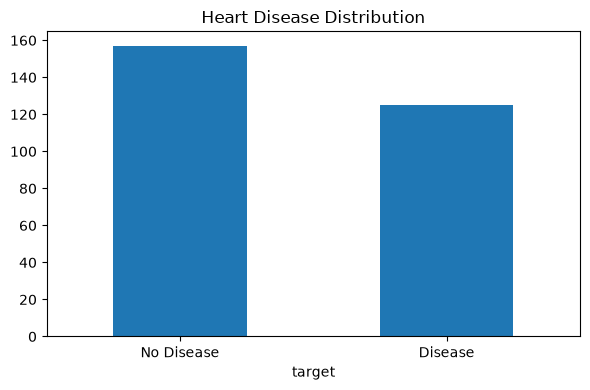

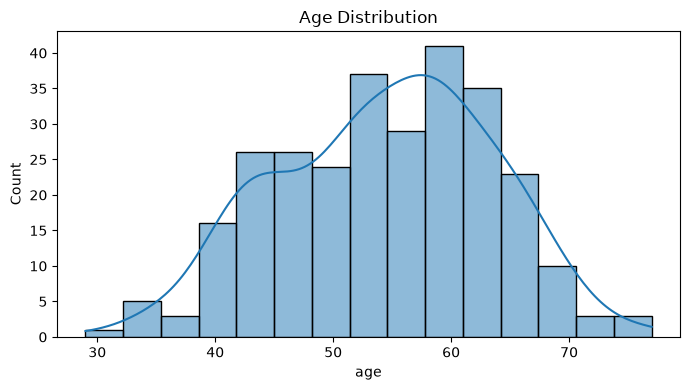

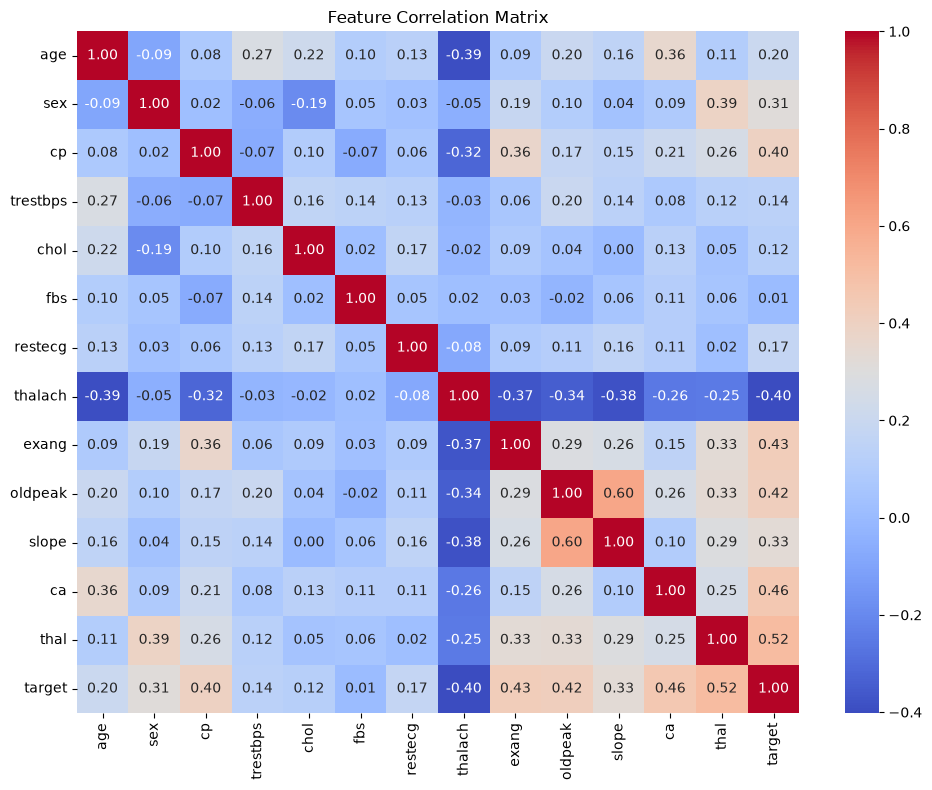

In [17]:
plt.figure(figsize=(6,4))
df['target'].value_counts().sort_index().plot(kind='bar')
plt.xticks([0,1], ['No Disease','Disease'], rotation=0)
plt.title('Heart Disease Distribution')
plt.tight_layout()
plt.savefig('output/heart_disease_distribution.png', dpi=300)
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(df['age'], bins=15, kde=True)
plt.title('Age Distribution')
plt.tight_layout()
plt.savefig('output/age_distribution.png', dpi=300)
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('output/correlation_matrix.png', dpi=300)
plt.show()

Accuracy: 0.807
ROC-AUC: 0.9125

Confusion Matrix:
 [[26  6]
 [ 5 20]]


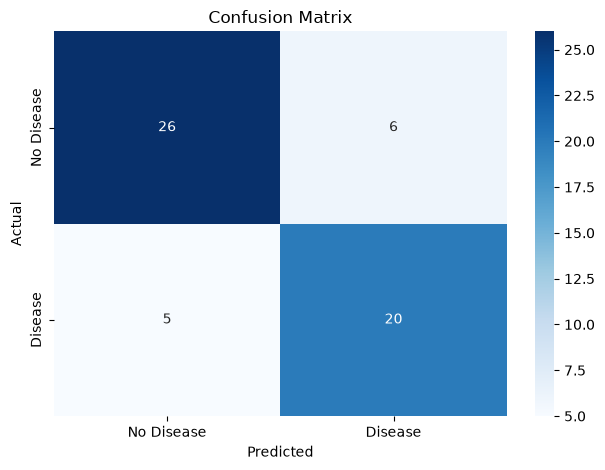

In [18]:
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:, 1]

print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, prob), 4))

cm = confusion_matrix(y_test, pred)
print('\nConfusion Matrix:\n', cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('output/confusion_matrix.png', dpi=300)
plt.show()

In [19]:
clinical_note = '''
Patient is a 58 year old male.
Patient reports chest pain and shortness of breath.
Blood pressure is elevated.
Patient has high cholesterol.
ECG examination is recommended.
'''

with open('data/clinical_note.txt', 'w', encoding='utf-8') as f:
    f.write(clinical_note)

tokens = re.sub(r'[^a-zA-Z0-9\s]', '', clinical_note.lower()).split()
stopwords = {'the','is','a','an','and','of','to','has','with','in','on','patient'}
filtered = [w for w in tokens if w not in stopwords]
freq = Counter(filtered)

print('Tokens:', tokens)
print('\nWord frequency:')
display(pd.DataFrame(freq.most_common(), columns=['Word','Frequency']))
print('\nKey terms:', [w for w, _ in freq.most_common(10)])

Tokens: ['patient', 'is', 'a', '58', 'year', 'old', 'male', 'patient', 'reports', 'chest', 'pain', 'and', 'shortness', 'of', 'breath', 'blood', 'pressure', 'is', 'elevated', 'patient', 'has', 'high', 'cholesterol', 'ecg', 'examination', 'is', 'recommended']

Word frequency:


,Word,Frequency
0,58,1
1,year,1
2,old,1
3,male,1
4,reports,1
5,chest,1
6,pain,1
7,shortness,1
8,breath,1
9,blood,1



Key terms: ['58', 'year', 'old', 'male', 'reports', 'chest', 'pain', 'shortness', 'breath', 'blood']


Format: PNG
Mode: L
Original size: (512, 512)
Array shape: (512, 512)
Normalized range: 0.0 to 0.7058823529411765
Resized size: (224, 224)


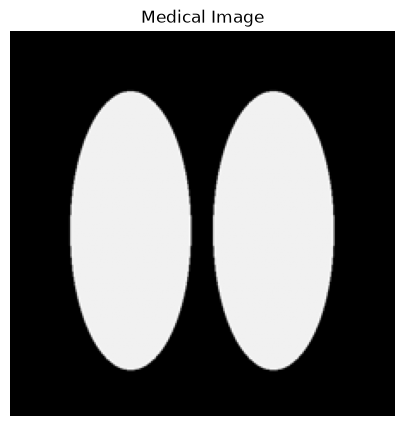

In [20]:
image_path = 'output/medical_image.png'

image = Image.new('L', (512, 512), 0)
draw = ImageDraw.Draw(image)
draw.ellipse((80, 80, 240, 450), fill=180)
draw.ellipse((270, 80, 430, 450), fill=180)
image.save(image_path)

image = Image.open(image_path)
arr = np.array(image)
normalized = arr / 255.0
resized = image.resize((224, 224))

print('Format:', image.format)
print('Mode:', image.mode)
print('Original size:', image.size)
print('Array shape:', arr.shape)
print('Normalized range:', normalized.min(), 'to', normalized.max())
print('Resized size:', resized.size)

plt.figure(figsize=(5,5))
plt.imshow(resized, cmap='gray')
plt.title('Medical Image')
plt.axis('off')
plt.savefig('output/medical_image_display.png', dpi=300, bbox_inches='tight')
plt.show()

Sampling frequency: 360 Hz
Samples: 650000
Channels: 2
Signal names: ['MLII', 'V5']


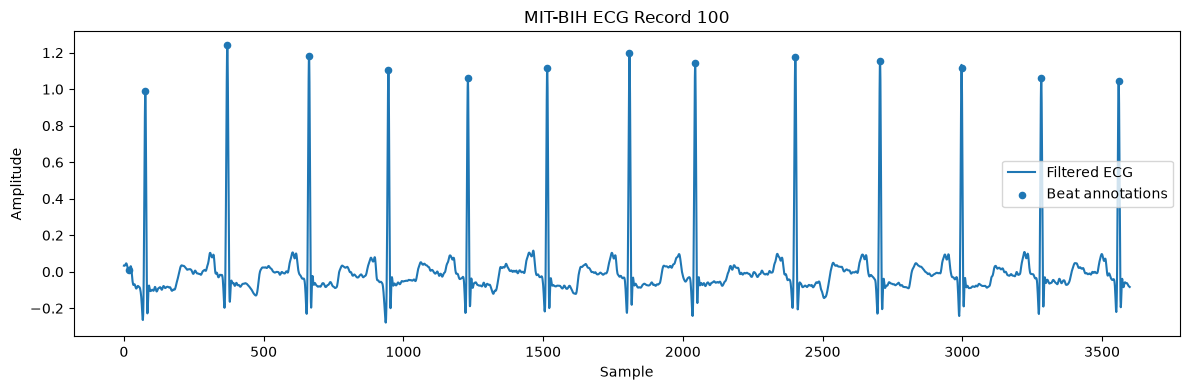

Mean RR interval: 0.7943 seconds
Approximate heart rate: 75.54 BPM
SDNN: 0.0506 seconds


In [21]:
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

ecg = record.p_signal[:, 0]
fs = record.fs

print('Sampling frequency:', fs, 'Hz')
print('Samples:', record.sig_len)
print('Channels:', record.n_sig)
print('Signal names:', record.sig_name)

b, a = butter(4, [0.5/(fs/2), 40/(fs/2)], btype='band')
filtered_ecg = filtfilt(b, a, ecg)

samples = min(int(fs * 10), len(ecg))
beats = annotation.sample[annotation.sample < samples]

plt.figure(figsize=(12,4))
plt.plot(filtered_ecg[:samples], label='Filtered ECG')
plt.scatter(beats, filtered_ecg[beats], s=20, label='Beat annotations')
plt.title('MIT-BIH ECG Record 100')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.savefig('output/ecg_signal.png', dpi=300)
plt.show()

rr = np.diff(annotation.sample) / fs
print('Mean RR interval:', round(rr.mean(), 4), 'seconds')
print('Approximate heart rate:', round(60 / rr.mean(), 2), 'BPM')
print('SDNN:', round(rr.std(), 4), 'seconds')

In [22]:
print('Medical modalities demonstrated:')
print('1. Tabular  - Cleveland Heart Disease')
print('2. Textual  - Clinical Note')
print('3. Image    - Medical Image')
print('4. Signal   - MIT-BIH ECG')
print('\nGenerated figures are saved in:', os.path.abspath('output'))
print('\nLAB EXPERIMENT 1 COMPLETED SUCCESSFULLY')

Medical modalities demonstrated:
1. Tabular  - Cleveland Heart Disease
2. Textual  - Clinical Note
3. Image    - Medical Image
4. Signal   - MIT-BIH ECG

Generated figures are saved in: /Users/harshilagrawal/Downloads/lab1/output

LAB EXPERIMENT 1 COMPLETED SUCCESSFULLY
